# 0. Helper Functions

This section defines functions for model training, evaluation, and visualization of results.

In [2]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from scipy.stats import uniform, randint
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import time
import matplotlib.pyplot as plt
import matplotlib

# matplotlib.rcParams.update({'font.size': 20})

# train SVM model using GridSearchCV
def train_svm(X_train, y_train):
    param_grid = {
        'C': [0.1, 1, 10],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.01, 0.1]
    }

    svr = SVR(kernel='rbf')

    grid_search = GridSearchCV(
        estimator=svr,
        param_grid=param_grid,
        cv=3,
        scoring='neg_mean_squared_error',
        verbose=2,
        n_jobs=-1
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


# train Random Forest model using GridSearchCV
def train_rf(X_train, y_train):
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [None, 10, 20],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt']
    }

    rf = RandomForestRegressor(random_state=42)

    grid_search = GridSearchCV(
        estimator=rf,
        param_grid=param_grid,
        cv=3,
        scoring='r2',
        verbose=2,
        n_jobs=-1
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


# train HistGradientBoostingRegressor model using RandomizedSearchCV
def train_histgb(X_train, y_train):
    param_dist = {
        'learning_rate': uniform(0.01, 0.1),
        'max_iter': randint(100, 300),
        'max_depth': randint(3, 10),
        'min_samples_leaf': randint(10, 50),
        'l2_regularization': uniform(0.0, 1.0)
    }

    model = HistGradientBoostingRegressor(
        early_stopping=True,
        random_state=42
    )

    grid_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=20,
        scoring='neg_mean_squared_error',
        cv=3,
        n_jobs=-1,
        verbose=2,
        random_state=42
    )

    start = time.time()
    grid_search.fit(X_train, y_train)
    end = time.time()

    return grid_search.best_estimator_, end - start


# model evaluation function
def evaluate_model(model, X_train, y_train, X_test, y_test, time=None):
    if time is not None:
        print(f"\n⏱️ Training Time: {time:.2f} seconds")

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_mse = mean_squared_error(y_train, train_pred)
    train_mae = mean_absolute_error(y_train, train_pred)
    train_r2 = r2_score(y_train, train_pred)

    test_mse = mean_squared_error(y_test, test_pred)
    test_mae = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)

    print(f"📊 Train MSE: {train_mse:.4f}, MAE: {train_mae:.4f}, R2: {train_r2:.4f}")
    print(f"📊 Test  MSE: {test_mse:.4f}, MAE: {test_mae:.4f}, R2: {test_r2:.4f}\n")

# def visualize_results(y_true, y_pred, title="Model Predictions vs True Values"):
#     plt.figure(figsize=(6, 6))
#     plt.scatter(y_true, y_pred, alpha=0.7)
#     plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
#     plt.xlim(0, 1)
#     plt.ylim(0, 1)
#     plt.xlabel('Prave vrijednosti pIC50')
#     plt.ylabel('Predicted pIC50 values')
#     plt.title(title)
#     plt.grid()
#     plt.tight_layout()
#     plt.show()

# 1. Data Preprocessing

This notebook explores how combining different molecular representations affects the quality of molecular property prediction. We start by loading a dataset of 479 molecules, consisting of ChEMBL_ID identifiers and their _pIC50_ values (potency). SMILES strings are then fetched from the ChEMBL database using the molecule identifiers. Molecules are validated and converted to canonical form to ensure unambiguous SMILES representations.

In [3]:
import pandas as pd
import numpy as np

# load data
data = pd.read_csv('data/dopamine.csv', index_col=0)
data

,ChEMBL_ID,pIC50
0,CHEMBL303519,5.01
1,CHEMBL292943,7.30
2,CHEMBL61682,7.60
3,CHEMBL64487,6.44
4,CHEMBL64597,6.52
...,...,...
474,CHEMBL3805434,7.42
475,CHEMBL3805327,7.23
476,CHEMBL3805262,5.80
477,CHEMBL3805515,6.70


In [4]:
import requests
from rdkit import Chem
import xmltodict

# fetch SMILES strings from the ChEMBL database
smiles = []
for mol_id in data.ChEMBL_ID:
    response = requests.get(f'https://www.ebi.ac.uk/chembl/api/data/molecule/{mol_id}')
    smiles.append(Chem.CanonSmiles(xmltodict.parse(response.text)['molecule']['molecule_structures']['canonical_smiles']))
data['smiles'] = smiles

In [5]:
data.head()

,ChEMBL_ID,pIC50,smiles
0,CHEMBL303519,5.01,c1cnc(N2CCN(Cc3cccc4c3Cc3ccccc3-4)CC2)nc1
1,CHEMBL292943,7.30,COc1ccc(-c2cccc(CN3CCN(c4ncccn4)CC3)c2)cc1
2,CHEMBL61682,7.60,Fc1ccc(-c2cncc(CN3CCN(c4ccccc4F)CC3)c2)cc1
3,CHEMBL64487,6.44,COc1ccccc1-c1cccc(CN2CCN(c3ncccn3)CC2)c1
4,CHEMBL64597,6.52,c1cnc(N2CCN(Cc3cccc(-c4ccsc4)c3)CC2)nc1


In [6]:
# check that all SMILES strings were fetched
data.isna().sum()

ChEMBL_ID    0
pIC50        0
smiles       0
dtype: int64

All records were fetched successfully with no missing data. The target feature _pIC50_ is then scaled to values between 0 and 1.

In [23]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data['pIC50'] = scaler.fit_transform(np.array(data['pIC50']).reshape(-1,1))
data.describe()

,pIC50
count,479.000000
mean,0.434002
std,0.213238
min,0.000000
25%,0.267928
50%,0.414343
75%,0.583665
max,1.000000


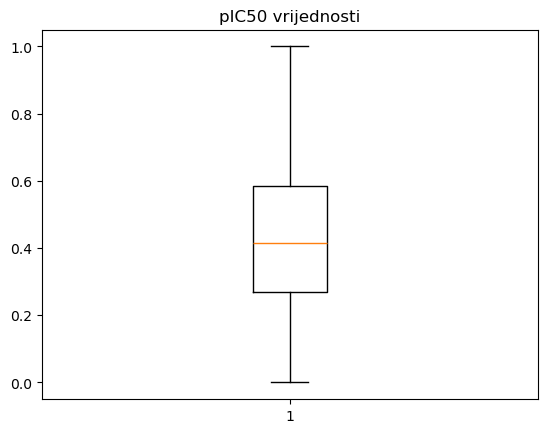

In [ ]:
# check for outliers
plt.boxplot(data['pIC50'])
plt.title('pIC50 values')
plt.show()

No outliers detected. The dataset is ready for further generation of molecular descriptors.

# 2. Molecular Representations
The following sections generate different molecular representations: molecular descriptors, molecular fingerprints, and latent-space representations obtained using Mol2Vec and ChemBERTa models.

## 2.1. Molecular Descriptors

Molecular descriptors are computed using the Mordred calculator. The process starts from SMILES strings, from which 2D structures are generated using RDKit. Since Mordred also supports three-dimensional descriptors, molecules are converted to 3D structures. Each molecule is then temporarily saved in SDF format, which allows storing three-dimensional atomic coordinates and molecular metadata.

In [25]:
from rdkit.Chem import AllChem
from mordred import Calculator, descriptors
import tempfile
import os

def generate_3d_conformer(mol):
    """
    Generate 3D conformer for a molecule.
    """
    mol = Chem.AddHs(mol)
    success = AllChem.EmbedMolecule(mol, randomSeed=42, useRandomCoords=True)
    if success == -1:
        return None
    try:
        AllChem.MMFFOptimizeMolecule(mol)
    except:
        try:
            AllChem.UFFOptimizeMolecule(mol)
        except:
            return None
    return mol

def smiles_to_sdf(df, smiles_col='smiles', id_col='ChEMBL_ID'):
    """
    Convert SMILES to SDF file with 3D conformers.
    """
    mols = []
    valid_indices = []

    for idx, row in df.iterrows():
        mol = Chem.MolFromSmiles(row[smiles_col])
        if mol is not None:
            mol_3d = generate_3d_conformer(mol)
            if mol_3d is not None:
                # Add properties to the molecule
                for col in df.columns:
                    if col != smiles_col:
                        mol_3d.SetProp(col, str(row[col]))
                mols.append(mol_3d)
                valid_indices.append(idx)
            else:
                print(f"Failed to generate 3D conformer for molecule {row[id_col]}")

    temp_sdf = tempfile.NamedTemporaryFile(suffix='.sdf', delete=False)
    writer = Chem.SDWriter(temp_sdf.name)

    for mol in mols:
        writer.write(mol)
    writer.close()

    return temp_sdf.name, valid_indices

def calculate_mordred_descriptors(sdf_file):
    """
    Calculate all Mordred descriptors including 3D.
    """
    calc = Calculator(descriptors, ignore_3D=False)
    mols = [mol for mol in Chem.SDMolSupplier(sdf_file) if mol is not None]
    df_descriptors = calc.pandas(mols)
    return df_descriptors

def generate_molecular_descriptors(data):
    print("Converting SMILES to 3D structures and generating SDF file...")
    sdf_file, valid_indices = smiles_to_sdf(df=data)

    try:
        print("Calculating descriptors...")
        descriptors_df = calculate_mordred_descriptors(sdf_file)

        # Combine the descriptors with the original data
        valid_data = data.iloc[valid_indices].reset_index(drop=True)
        final_dataset = pd.concat([valid_data.reset_index(drop=True), descriptors_df.reset_index(drop=True)], axis=1)

        # Save the complete dataset
        final_dataset.to_csv('molecular_features.csv', index=False)

        # Print summary statistics
        print("\nDataset Summary:")
        print(f"Total molecules processed: {len(final_dataset)}")
        print(f"Total features generated: {len(final_dataset.columns)}")

    finally:
        # Clean up temporary file
        os.remove(sdf_file)

    return final_dataset

In [26]:
data = generate_molecular_descriptors(data)

Converting SMILES to 3D structures and generating SDF file...


Calculating descriptors...


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)



Dataset Summary:
Total molecules processed: 479
Total features generated: 1829


Using Mordred, 1826 descriptors are computed per molecule, but a significant number are invalid. In practice, many descriptors can only be computed for specific molecules (e.g., organic ones), while others produce errors — often due to undefined operations such as division by zero. Such descriptors are removed from the dataset, along with those with very low variance (constant for most molecules). The variance threshold is set to $0.16$ (descriptors whose values are constant in ≥ 80% of samples).

In [27]:
from sklearn.feature_selection import VarianceThreshold

def prepare_features(descriptors_df):
    """
    Clean and prepare descriptors for machine learning while preserving specified columns.
    Applies VarianceThreshold for low-variance feature selection.
    """
    # Columns to preserve
    string_columns_to_preserve = ['ChEMBL_ID', 'smiles', 'pIC50']

    # Separate preserved columns
    preserved_columns = descriptors_df[string_columns_to_preserve]

    # Work on the remaining numeric columns
    numeric_df = descriptors_df.drop(columns=string_columns_to_preserve, errors='ignore')
    print("Number of descriptors before cleaning:", numeric_df.shape[1])

    # Convert all to numeric, replacing non-numeric with NaN
    numeric_df = numeric_df.apply(pd.to_numeric, errors='coerce')

    # Remove columns with any NaN values
    numeric_df = numeric_df.dropna(axis=1)
    print("Number of descriptors after removing NaN values:", numeric_df.shape[1])

    # Apply VarianceThreshold for low-variance feature selection
    selection = VarianceThreshold(threshold=(.8 * (1 - .8)))  # Threshold = 0.16 (80% * (1-80%))
    numeric_df_array = selection.fit_transform(numeric_df)  # Transform to array

    # Convert back to DataFrame, retaining column names post-selection
    selected_columns = numeric_df.columns[selection.get_support()]
    numeric_df = pd.DataFrame(numeric_df_array, columns=selected_columns)

    # Combine preserved columns back with cleaned numeric data
    final_df = pd.concat([preserved_columns.reset_index(drop=True), numeric_df.reset_index(drop=True)], axis=1)
    print("Number of descriptors after cleaning:", final_df.shape[1])

    return final_df

In [28]:
data = prepare_features(data)

Number of descriptors before cleaning: 1826
Number of descriptors after removing NaN values: 1164
Number of descriptors after cleaning: 559


Although the number of features has been significantly reduced, 500+ descriptors still represents high dimensionality for machine learning. Further selection of the most informative descriptors is therefore needed.

Before feature selection, the dataset is split into training and test sets, since the models used later in this notebook require training. The training set is used to fit dimensionality reduction models and, subsequently, the predictive models, while the test set is used to evaluate performance and generalization of the predictive models.

In [29]:
from sklearn.model_selection import train_test_split

data_train, data_test = train_test_split(data, test_size=0.25, random_state=42)
len(data_train), len(data_test)

(359, 120)

The molecular descriptor selection process involves several steps:
1. Removal of autocorrelation descriptors, which are often redundant and less interpretable
2. Scaling descriptor values to the range [0, 1]
3. Feature importance estimation using a Random Forest algorithm
4. Removal of highly correlated features using Pearson's coefficient — all pairs of molecular descriptors with a Pearson coefficient above 0.9 are identified, and the descriptor with lower importance is removed
5. Recursive Feature Elimination with Cross-Validation (RFECV) — a supervised feature selection method that selects the optimal number of features based on the coefficient of determination

Feature selection is performed on the training sets.

In [30]:
import matplotlib.pyplot as plt
from sklearn.feature_selection import RFECV

def efficient_feature_selection(X: pd.DataFrame,
                                y: pd.Series,
                                min_features: int = 20,
                                max_features: int = 30,
                                random_state: int = 42,
                                scale = True):
    """
    Efficient feature selection using a two-step approach:
    1. Remove autocorrelation descriptors
    2. Initial feature reduction using RandomForest importance
    3. Fine-tuning using RFECV with reduced feature set
    4. Post-processing to remove one of two highly correlated features.

    Args:
        X: Feature DataFrame
        y: Target Series
        min_features: Minimum number of features to select
        max_features: Maximum number of features for initial filtering
        random_state: Random seed for reproducibility

    Returns:
        Tuple of (selected features DataFrame, list of feature names)
    """
    orig_num = len(X.columns)

    # Step 0: Remove autocorrelation descriptors
    autocorr_keywords = ["ATSC", "AATS"]  # Keywords to identify autocorrelation descriptors
    autocorr_features = [
        col for col in X.columns if any(keyword in col for keyword in autocorr_keywords)
    ]
    X = X.drop(columns=autocorr_features)

    print(f"Removed {len(autocorr_features)} autocorrelation descriptors.")

    # Step 1: Scale the features
    if scale:
        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X.to_numpy())
        X_scaled = pd.DataFrame(X_scaled, columns=X.columns)
    else:
        X_scaled = X.copy()

    # Step 2: Initial feature reduction using RandomForest importance
    pre_selector = RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        n_jobs=-1,
        random_state=random_state
    )

    pre_selector.fit(X_scaled, y)

    # Get feature importance and select top features
    importances = pd.Series(pre_selector.feature_importances_, index=X.columns)
    importances_sorted = importances.sort_values(ascending=False)

    # Select top features (max_features or 2 * target_features, whichever is smaller)
    n_features_to_keep = min(max_features, len(importances_sorted))
    top_features = importances_sorted.head(n_features_to_keep).index.tolist()

    # Step 3: Filter to top features
    X_reduced = X_scaled[top_features]

    # Step 4: Post-processing - Remove highly correlated features
    # Calculate Pearson correlation
    corr_matrix = X_reduced.corr(method='pearson').abs()
    upper_triangle = np.triu(np.ones(corr_matrix.shape), k=1)
    upper_corr_matrix = pd.DataFrame(corr_matrix.values * upper_triangle,
                                     columns=corr_matrix.columns,
                                     index=corr_matrix.index)

    # Identify pairs of highly correlated features
    high_corr_pairs = [(col1, col2)
                       for col1 in upper_corr_matrix.columns
                       for col2 in upper_corr_matrix.index
                       if upper_corr_matrix.loc[col2, col1] > 0.9]  # Threshold for correlation

    # Remove the feature with the smaller importance from each pair
    features_to_remove = set()
    for feat1, feat2 in high_corr_pairs:
        if feat1 in importances and feat2 in importances:
            # Compare importance and remove the less important feature
            if importances[feat1] > importances[feat2]:
                features_to_remove.add(feat2)
            else:
                features_to_remove.add(feat1)

    # Remove highly correlated features
    X_reduced = X_reduced.drop(columns=list(features_to_remove))
    top_features = [feat for feat in top_features if feat not in features_to_remove]
    print("Removed highly correlated features:", len(features_to_remove))

    # Step 5: RFECV on reduced feature set
    rf_model = RandomForestRegressor(
        n_estimators=500,
        max_depth=15,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=random_state
    )

    rfecv = RFECV(
        estimator=rf_model,
        step=1,
        cv=5,
        scoring="r2",
        n_jobs=-1,
        min_features_to_select=min_features,
        verbose=0
    )

    rfecv.fit(X_reduced, y)

    # Get final selected features
    final_features = X_reduced.columns[rfecv.support_].tolist()

    # Calculate final feature importance
    final_importance = pd.Series(
        rfecv.estimator_.feature_importances_,
        index=final_features
    ).sort_values(ascending=False)

    print(f'Number of features reduced from {orig_num} to {len(final_features)}.')

    return X[final_features], final_features, final_importance

def plot_importance(selected_features, final_importance):
    # final_importance_scaled = (final_importance - min(final_importance)) / (max(final_importance) - min(final_importance))
    importances_rfe = dict(zip(selected_features, final_importance))
    plt.barh(selected_features, final_importance)
    plt.show()
    print(importances_rfe)

In [31]:
X_descriptors_train = data_train.drop(columns=['pIC50', 'ChEMBL_ID', 'smiles']).copy()
X_descriptors_test = data_test.drop(columns=['pIC50', 'ChEMBL_ID', 'smiles']).copy()

y_train = np.array(data_train['pIC50'])
y_test = np.array(data_test['pIC50'])

Removed 156 autocorrelation descriptors.
Removed highly correlated features: 7
Number of features reduced from 556 to 23.


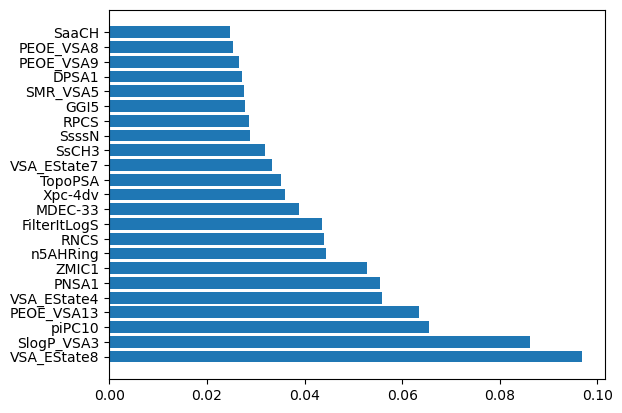

{'VSA_EState8': 0.0968000506083811, 'SlogP_VSA3': 0.08625138291670717, 'piPC10': 0.06544386171586801, 'PEOE_VSA13': 0.06351077793429602, 'VSA_EState4': 0.055787276584265605, 'PNSA1': 0.05546195341609066, 'ZMIC1': 0.052829940761726514, 'n5AHRing': 0.04447338479281062, 'RNCS': 0.044063764811327476, 'FilterItLogS': 0.04349127082477701, 'MDEC-33': 0.03878210285876878, 'Xpc-4dv': 0.03602767773643963, 'TopoPSA': 0.0351492873134306, 'VSA_EState7': 0.033251379328874515, 'SsCH3': 0.03184916456681196, 'SsssN': 0.02892274522846046, 'RPCS': 0.028613484534279813, 'GGI5': 0.02776279374655961, 'SMR_VSA5': 0.02759924863401505, 'DPSA1': 0.027213546866181826, 'PEOE_VSA9': 0.026590822696403987, 'PEOE_VSA8': 0.025334668569180104, 'SaaCH': 0.024789413554343515}


In [32]:
X_selected_descriptors, selected_features_descriptors, final_importance_descriptors = efficient_feature_selection(
    X = X_descriptors_train,
    y = y_train,
    min_features = 20,
    max_features = 30
)

plot_importance(selected_features_descriptors, final_importance_descriptors)


156 autocorrelation descriptors and an additional 7 highly correlated features were removed. After RFECV selection, 23 descriptors remain.

In [ ]:
# store selected features in X_train and X_test
X_descriptors_train = X_selected_descriptors.copy()
X_descriptors_test = X_descriptors_test[X_selected_descriptors.columns]

## 2.2. Molecular Fingerprints

Four types of molecular fingerprints (MACCS, Avalon, ECFP, and ErG) are generated using RDKit. Although initially implemented as specialized objects, all fingerprints are converted to binary vectors for simpler processing.

In [34]:
from rdkit.Chem import MACCSkeys
from rdkit.Chem.Pharm2D import Generate
from rdkit.Chem.Pharm2D import Gobbi_Pharm2D
from rdkit.DataStructs import ConvertToNumpyArray
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Avalon import pyAvalonTools

# MACCS
def maccs_to_numpy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = MACCSkeys.GenMACCSKeys(mol)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr
data_train['maccs'] = data_train['smiles'].apply(maccs_to_numpy)
data_test['maccs'] = data_test['smiles'].apply(maccs_to_numpy)

# Avalon
data_train['avalon'] = data_train['smiles'].apply(
    lambda x: np.array(pyAvalonTools.GetAvalonFP(AllChem.MolFromSmiles(x), nBits=512)))
data_test['avalon'] = data_test['smiles'].apply(
    lambda x: np.array(pyAvalonTools.GetAvalonFP(AllChem.MolFromSmiles(x), nBits=512)))

# Morgan
morgan_gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=512)
data_train['morgan'] = data_train['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))
data_test['morgan'] = data_test['smiles'].apply(
    lambda x: np.array(list(morgan_gen.GetFingerprint(Chem.MolFromSmiles(x)).ToBitString()), dtype=int))

# ErG (2D Pharmacophore / Scaffold hopping)
factory = Gobbi_Pharm2D.factory
def erg_to_numpy(smiles):
    mol = Chem.MolFromSmiles(smiles)
    fp = Generate.Gen2DFingerprint(mol, factory)
    arr = np.zeros((fp.GetNumBits(),), dtype=int)
    ConvertToNumpyArray(fp, arr)
    return arr
data_train['erg'] = data_train['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))
data_test['erg'] = data_test['smiles'].apply(
    lambda x: Generate.Gen2DFingerprint(Chem.MolFromSmiles(x), factory))

In [35]:
print(len(data_train['maccs'].tolist()[0]), len(data_train['avalon'].tolist()[0]),
       len(data_train['morgan'].tolist()[0]), len(data_train['erg'].tolist()[0]))

167 512 512 39972


After conversion to binary vectors, MACCS fingerprints have dimension 167, Avalon and ECFP fingerprints have dimension 512, and ErG has dimension 39,972. Dimensionality reduction to 128 bits is applied to all molecular fingerprints.

Fingerprint dimensionality reduction is performed in two steps: removal of near-constant features followed by SVD decomposition. Removing near-constant features eliminates values that are identical for most molecules and therefore lack discriminative power. SVD (Singular Value Decomposition) is a linear method that decomposes the fingerprint matrix.

In [36]:
from sklearn.decomposition import TruncatedSVD

def reduce_fp(X_train, X_test):
    # X := (num_samples x 39972) numpy array

    # 1) Remove near-zero variance features
    selector = VarianceThreshold(threshold=0.001)  # tune threshold
    X_var_train = selector.fit_transform(X_train)
    X_var_test = selector.transform(X_test)

    print(f"After variance thresholding: {X_var_test.shape}")

    # 2) Use TruncatedSVD to reduce dimensionality
    svd = TruncatedSVD(n_components=128, random_state=42)  # choose n_components based on explained variance or downstream task
    X_reduced_train = svd.fit_transform(X_var_train)
    X_reduced_test = svd.transform(X_var_test)

    print(f"After TruncatedSVD: {X_reduced_train.shape}\n")
    return X_reduced_train, X_reduced_test

X_maccs_train, X_maccs_test = reduce_fp(np.array(data_train['maccs'].tolist()), np.array(data_test['maccs'].tolist()))
X_avalon_train, X_avalon_test = reduce_fp(np.array(data_train['avalon'].tolist()), np.array(data_test['avalon'].tolist()))
X_morgan_train, X_morgan_test = reduce_fp(np.array(data_train['morgan'].tolist()), np.array(data_test['morgan'].tolist()))
X_erg_train, X_erg_test = reduce_fp(np.array(data_train['erg'].tolist()), np.array(data_test['erg'].tolist()))

After variance thresholding: (120, 144)
After TruncatedSVD: (359, 128)

After variance thresholding: (120, 511)
After TruncatedSVD: (359, 128)

After variance thresholding: (120, 507)
After TruncatedSVD: (359, 128)

After variance thresholding: (120, 7973)
After TruncatedSVD: (359, 128)



All fingerprints are concatenated into a single composite representation for training and evaluation of predictive models.

In [37]:
X_fp_train = np.hstack([X_maccs_train, X_avalon_train, X_morgan_train, X_erg_train])
X_fp_test = np.hstack([X_maccs_test, X_avalon_test, X_morgan_test, X_erg_test])

## 2.3. Mol2Vec

A pre-trained Mol2Vec model is used to generate the first type of latent molecular representations. Before using it, SMILES strings are converted to 2D structures using RDKit. The resulting molecules then serve as input to the Mol2Vec model, which transforms SMILES strings into latent representations.

In [38]:
from tqdm import tqdm

# zbog nekompatibilnosti verzija
def sentences2vec(sentences, model, unseen='UNK'):
    """
    Convert a list of sentences (molecular substructure tokens) into vector representations
    using a gensim Word2Vec model (Gensim 4.x compatible).

    Parameters:
    - sentences: list of lists of substructure tokens (e.g., [['[C@@H]', '[CH3]'], ...])
    - model: gensim Word2Vec model (must be trained or preloaded)
    - unseen: token to use for unseen words (default 'UNK')

    Returns:
    - list of numpy arrays (each array = vector for one molecule)
    """
    vectors = []
    for sentence in tqdm(sentences, desc="Embedding molecules"):
        vecs = []
        for word in sentence:
            if word in model.wv:
                vecs.append(model.wv[word])
            elif unseen in model.wv:
                vecs.append(model.wv[unseen])
        if vecs:
            vectors.append(np.mean(vecs, axis=0))
        else:
            # In case no known words in sentence, use zero vector
            vectors.append(np.zeros(model.vector_size))
    return vectors


In [39]:
import gensim
from mol2vec.features import mol2alt_sentence
# from tqdm import tqdm
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

# Load model
model = gensim.models.Word2Vec.load("models/model_300dim.pkl")
sentences_train = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_train['smiles'].tolist()]
sentences_test = [mol2alt_sentence(Chem.MolFromSmiles(smi), radius=1) for smi in data_test['smiles'].tolist()]

# Convert to vectors
vectors_train = sentences2vec(sentences_train, model)
vectors_test = sentences2vec(sentences_test, model)
data_train['mol2vec'] = vectors_train
data_test['mol2vec'] = vectors_test

In [40]:
len(data_train['mol2vec'].tolist()[0])

300

To facilitate later training and comparison of predictive models, dimensionality was reduced from 300 to 128 using an autoencoder.

The autoencoder consists of an input layer, a single dense layer serving as the encoder, and another dense layer serving as the decoder. The model was trained for 50 epochs on the training set using batches of 32 molecules.

In [41]:
from tensorflow.keras import layers, models

def reduce_embedding_dim(X_train, X_test):
    """
    Reduce the dimensionality of embeddings using an autoencoder.
    """

    # Define autoencoder architecture
    input_dim = X_train.shape[1]
    encoding_dim = 128  # or whatever target dimension you want

    input_layer = layers.Input(shape=(input_dim,))
    encoded = layers.Dense(encoding_dim, activation='relu')(input_layer)
    decoded = layers.Dense(input_dim, activation='linear')(encoded)

    autoencoder = models.Model(input_layer, decoded)
    encoder = models.Model(input_layer, encoded)  # This gives compressed output

    # Compile and train
    autoencoder.compile(optimizer='adam', loss='mse')
    autoencoder.fit(X_train, X_train, epochs=50, batch_size=32, shuffle=True)

    X_reduced_train = encoder.predict(X_train)
    X_reduced_test = encoder.predict(X_test)
    
    return X_reduced_train, X_reduced_test

X_mol2vec_train, X_mol2vec_test = reduce_embedding_dim(np.array([emb for emb  in data_train['mol2vec']]), 
                                                       np.array([emb for emb in data_test['mol2vec']]))

Epoch 1/50
12/12 [==============================] - 1s 3ms/step - loss: 0.0087
Epoch 2/50
12/12 [==============================] - 0s 2ms/step - loss: 0.0021
Epoch 3/50
12/12 [==============================] - 0s 2ms/step - loss: 0.0011
Epoch 4/50
12/12 [==============================] - 0s 1ms/step - loss: 9.6435e-04
Epoch 5/50
12/12 [==============================] - 0s 1ms/step - loss: 8.6752e-04
Epoch 6/50
12/12 [==============================] - 0s 1ms/step - loss: 8.0137e-04
Epoch 7/50
12/12 [==============================] - 0s 1ms/step - loss: 7.3703e-04
Epoch 8/50
12/12 [==============================] - 0s 1ms/step - loss: 6.7886e-04
Epoch 9/50
12/12 [==============================] - 0s 1ms/step - loss: 6.2447e-04
Epoch 10/50
12/12 [==============================] - 0s 1ms/step - loss: 5.8045e-04
Epoch 11/50
12/12 [==============================] - 0s 1ms/step - loss: 5.4577e-04
Epoch 12/50
12/12 [==============================] - 0s 1ms/step - loss: 5.1309e-04
Epoch 13/50
1

## 2.4. ChemBERTa

Generating the second type of latent representations using ChemBERTa is a somewhat more complex and time-consuming process. This model is also pre-trained on a large number of molecules, but here it is additionally fine-tuned on the potency prediction training set. Training is carried out for 20 epochs using 3-fold cross-validation, with the Adam optimizer at a learning rate of 10⁻⁵. After fine-tuning, the model is used to generate latent representations for molecules in the test set.

In [42]:
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification
import torch.nn as nn
import torch
from torch.utils.data import Dataset

model_name = "seyonec/ChemBERTa-zinc-base-v1"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(smiles):
    return tokenizer(smiles, padding=True, truncation=True, return_tensors='pt')

class SMILESDataset(Dataset):
    def __init__(self, smiles_list, targets):
        self.inputs = tokenizer(smiles_list, padding=True, truncation=True, return_tensors='pt')
        self.targets = torch.tensor(targets).float().unsqueeze(1)
    
    def __len__(self):
        return len(self.targets)
    
    def __getitem__(self, idx):
        return (
            self.inputs['input_ids'][idx],
            self.inputs['attention_mask'][idx],
            self.targets[idx]
        )
    
class ChemBERTaRegressor(nn.Module):
    def __init__(self, model_name):
        super().__init__()
        self.chemberta = AutoModel.from_pretrained(model_name)
        self.regressor = nn.Linear(self.chemberta.config.hidden_size, 1)

    def forward(self, input_ids, attention_mask):
        outputs = self.chemberta(input_ids=input_ids, attention_mask=attention_mask)
        pooled_output = outputs.last_hidden_state[:, 0, :]  # CLS token
        return self.regressor(pooled_output), pooled_output  # return both prediction and embedding


def train_model(model, dataloader, optimizer, device):
    model.train()
    for input_ids, attn_mask, targets in dataloader:
        input_ids, attn_mask, targets = input_ids.to(device), attn_mask.to(device), targets.to(device)
        preds, _ = model(input_ids, attn_mask)
        loss = nn.MSELoss()(preds, targets)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()


In [43]:
from sklearn.model_selection import KFold
import torch
from torch.utils.data import TensorDataset, DataLoader, Subset
from torch.optim import Adam
from torch.utils.data import Dataset


smiles_list = data_train['smiles'].tolist()
targets = data_train['pIC50'].tolist()

inputs = tokenize(smiles_list)
X = inputs['input_ids']
attention = inputs['attention_mask']
y = torch.tensor(targets).float().unsqueeze(1)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_EPOCHS = 20
N_SPLITS = 3

for epoch in range(N_EPOCHS):
    print(f"\n=== Epoch {epoch+1} ===")
    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=epoch)  # New shuffle per epoch

    fold_mse_list = []

    for fold, (train_idx, val_idx) in enumerate(kf.split(smiles_list)):
        print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")

        # Split data
        train_smiles = [smiles_list[i] for i in train_idx]
        val_smiles = [smiles_list[i] for i in val_idx]
        train_targets = y[train_idx]
        val_targets = y[val_idx]

        # Dataset and loaders
        train_dataset = SMILESDataset(train_smiles, train_targets)
        val_dataset = SMILESDataset(val_smiles, val_targets)
        train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
        val_loader = DataLoader(val_dataset, batch_size=32)

        # New model per fold
        model = ChemBERTaRegressor(model_name).to(device)
        optimizer = Adam(model.parameters(), lr=2e-5)

        # Train model for 1 epoch only (we’re inside the global epoch loop)
        train_model(model, train_loader, optimizer, device)

        # Evaluate on validation fold
        model.eval()
        all_preds, all_targets = [], []

        with torch.no_grad():
            for input_ids, attn_mask, targets in val_loader:
                input_ids, attn_mask = input_ids.to(device), attn_mask.to(device)
                preds, _ = model(input_ids, attn_mask)
                all_preds.append(preds.cpu())
                all_targets.append(targets)

        preds_cat = torch.cat(all_preds).squeeze()
        targets_cat = torch.cat(all_targets).squeeze()
        mse = nn.MSELoss()(preds_cat, targets_cat)
        fold_mse_list.append(mse.item())
        print(f"Fold {fold+1} MSE: {mse.item():.4f}")

    epoch_avg_mse = sum(fold_mse_list) / N_SPLITS
    print(f"\n✅ Epoch {epoch+1} Average MSE across folds: {epoch_avg_mse:.4f}")



=== Epoch 1 ===

--- Fold 1/3 ---


Fold 1 MSE: 0.1296

--- Fold 2/3 ---


Fold 2 MSE: 0.0816

--- Fold 3/3 ---
Fold 3 MSE: 0.1166

✅ Epoch 1 Average MSE across folds: 0.1092

=== Epoch 2 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.1046

--- Fold 2/3 ---
Fold 2 MSE: 0.1544

--- Fold 3/3 ---
Fold 3 MSE: 0.0752

✅ Epoch 2 Average MSE across folds: 0.1114

=== Epoch 3 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.1438

--- Fold 2/3 ---
Fold 2 MSE: 0.0640

--- Fold 3/3 ---
Fold 3 MSE: 0.0668

✅ Epoch 3 Average MSE across folds: 0.0915

=== Epoch 4 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.1143

--- Fold 2/3 ---
Fold 2 MSE: 0.1395

--- Fold 3/3 ---
Fold 3 MSE: 0.0967

✅ Epoch 4 Average MSE across folds: 0.1168

=== Epoch 5 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0844

--- Fold 2/3 ---
Fold 2 MSE: 0.0622

--- Fold 3/3 ---
Fold 3 MSE: 0.1218

✅ Epoch 5 Average MSE across folds: 0.0895

=== Epoch 6 ===

--- Fold 1/3 ---
Fold 1 MSE: 0.0903

--- Fold 2/3 ---
Fold 2 MSE: 0.1062

--- Fold 3/3 ---
Fold 3 MSE: 0.0955

✅ Epoch 6 Average MSE across folds: 0.0973

=== Epoch 7 ===

--- Fold 1/3 ---
Fold 

In [44]:
model.eval()
with torch.no_grad():
    y_chemberta_train, embeddings = model(X.to(device), attention.to(device))
embeddings = embeddings.cpu().numpy()
data_train['embedding'] = [np.array(emb) for emb in embeddings]


inputs_test = tokenize(data_test['smiles'].tolist())
X_test = inputs_test['input_ids']
attention_test = inputs_test['attention_mask']
y_test = torch.tensor(data_test['pIC50'].tolist()).float().unsqueeze(1)

with torch.no_grad():
    y_chemberta_test, embeddings_test = model(X_test.to(device), attention_test.to(device))
embeddings_test = embeddings_test.cpu().numpy()
data_test['embedding'] = [np.array(emb) for emb in embeddings_test]

In [45]:
len(data_train['embedding'].tolist()[0])

768

The dimensionality of the latent representation is reduced in the same way as for Mol2Vec, using an autoencoder.

In [46]:
X_chemberta_train, X_chemberta_test = reduce_embedding_dim(np.array([emb for emb in data_train['embedding']]), 
                                                           np.array([emb for emb in data_test['embedding']]))

Epoch 1/50
12/12 [==============================] - 0s 2ms/step - loss: 0.7608
Epoch 2/50
12/12 [==============================] - 0s 2ms/step - loss: 0.3053
Epoch 3/50
12/12 [==============================] - 0s 2ms/step - loss: 0.2339
Epoch 4/50
12/12 [==============================] - 0s 2ms/step - loss: 0.2059
Epoch 5/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1861
Epoch 6/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1683
Epoch 7/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1523
Epoch 8/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1389
Epoch 9/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1281
Epoch 10/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1199
Epoch 11/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1134
Epoch 12/50
12/12 [==============================] - 0s 2ms/step - loss: 0.1081
Epoch 13/50
12/12 [==============================

The following functions handle saving and loading the generated molecular representations, so that time-consuming procedures do not need to be repeated from scratch.

In [2]:
import pickle
import numpy as np

# # TRAIN SET
# with open("./data/X_descriptors_train.pkl", "wb") as f:
#     pickle.dump(X_descriptors_train, f)

# with open("./data/X_fp_train.pkl", "wb") as f:
#     pickle.dump(X_fp_train, f)

# with open("./data/X_mol2vec_train.pkl", "wb") as f:
#     pickle.dump(X_mol2vec_train, f)

# with open("./data/X_chemberta_train.pkl", "wb") as f:
#     pickle.dump(X_chemberta_train, f)

# with open("./data/data_train.pkl", "wb") as f:
#     pickle.dump(data_train, f)

# # TEST SET
# with open("./data/X_descriptors_test.pkl", "wb") as f:
#     pickle.dump(X_descriptors_test, f)

# with open("./data/X_fp_test.pkl", "wb") as f:
#     pickle.dump(X_fp_test, f)

# with open("./data/X_mol2vec_test.pkl", "wb") as f:
#     pickle.dump(X_mol2vec_test, f)

# with open("./data/X_chemberta_test.pkl", "wb") as f:
#     pickle.dump(X_chemberta_test, f)

# with open("./data/data_test.pkl", "wb") as f:
#     pickle.dump(data_test, f)



with open("./data/X_descriptors_train.pkl", "rb") as f:
    X_descriptors_train = pickle.load(f)

with open("./data/X_fp_train.pkl", "rb") as f:
    X_fp_train = pickle.load(f)

with open("./data/X_mol2vec_train.pkl", "rb") as f:
    X_mol2vec_train = pickle.load(f)

with open("./data/X_chemberta_train.pkl", "rb") as f:
    X_chemberta_train = pickle.load(f)

with open("./data/data_train.pkl", "rb") as f:
    data_train = pickle.load(f)

with open("./data/X_descriptors_test.pkl", "rb") as f:
    X_descriptors_test = pickle.load(f)

with open("./data/X_fp_test.pkl", "rb") as f:
    X_fp_test = pickle.load(f)

with open("./data/X_mol2vec_test.pkl", "rb") as f:
    X_mol2vec_test = pickle.load(f)

with open("./data/X_chemberta_test.pkl", "rb") as f:
    X_chemberta_test = pickle.load(f)

with open("./data/data_test.pkl", "rb") as f:
    data_test = pickle.load(f)

# 3. Comparison of Predictive Models

Three predictive models are used for molecular property prediction: Random Forest (RF), Support Vector Machine (SVM), and HistGradientBoostingRegressor (HGBR).

Each model is trained separately on four different types of molecular representations: molecular descriptors, a combined set of molecular fingerprints, Mol2Vec latent representations, and ChemBERTa latent representations. The latter two are treated separately due to their different nature and the NLP techniques applied, enabling comparison of their performance.

Models are also trained on combined molecular representations formed by concatenating different feature sets into a single vector. The results will indicate whether combining different molecular representations improves predictive performance.

To further test the combined-representation approach, models trained on each of the four representation types are assembled into a stacking ensemble. Ridge regression — a form of linear regression with L2 regularization — is used as the meta-model. Ridge regression is preferred here because it is robust to correlated inputs, less prone to overfitting, computationally efficient, and has proven effective in ensemble learning.

Before training, all input molecular features are standardized to the same scale.

In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_descriptors_train = scaler.fit_transform(X_descriptors_train.values)
X_descriptors_test = scaler.transform(X_descriptors_test.values)

X_fp_train = scaler.fit_transform(X_fp_train)
X_fp_test = scaler.transform(X_fp_test)

X_mol2vec_train = scaler.fit_transform(X_mol2vec_train)
X_mol2vec_test = scaler.transform(X_mol2vec_test)

X_chemberta_train = scaler.fit_transform(X_chemberta_train)
X_chemberta_test = scaler.transform(X_chemberta_test)

RF and SVM models are trained with 3-fold cross-validation on the training set. Hyperparameter optimization for RF and SVM is performed separately for each model using Grid Search.

HGBR hyperparameter optimization is performed using Randomized Search.

Predictive model performance is evaluated using three metrics: Mean Squared Error (MSE), Mean Absolute Error (MAE), and the coefficient of determination R².

In [4]:
X_combined_train = np.hstack([
    X_descriptors_train,
    X_fp_train,
    X_mol2vec_train,
    X_chemberta_train
])

y_train = np.array(data_train['pIC50'])

X_combined_test = np.hstack([
    X_descriptors_test,
    X_fp_test,
    X_mol2vec_test,
    X_chemberta_test
])

y_test = np.array(data_test['pIC50'])

## 3.1. RF

In [10]:
# molekularni deskriptori
print('Molecular descriptors')
rf_descriptors, rf_descriptors_time = train_rf(X_descriptors_train, y_train)
evaluate_model(rf_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, rf_descriptors_time)

# molekularni otisci
print('Molecular fingerprints')
rf_fp, rf_fp_time = train_rf(X_fp_train, y_train)
evaluate_model(rf_fp, X_fp_train, y_train, X_fp_test, y_test, rf_fp_time)

# mol2vec
print('Mol2Vec')
rf_mol2vec, rf_mol2vec_time = train_rf(X_mol2vec_train, y_train)
evaluate_model(rf_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, rf_mol2vec_time)

# chemberta
print('Chemberta')
rf_chemberta, rf_chemberta_time = train_rf(X_chemberta_train, y_train)
evaluate_model(rf_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, rf_chemberta_time)

Molecular descriptors
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 1.59 seconds
📊 Train MSE: 0.0043, MAE: 0.0508, R2: 0.9006
📊 Test  MSE: 0.0315, MAE: 0.1425, R2: 0.3627

Molecular fingerprints
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 3.01 seconds
📊 Train MSE: 0.0044, MAE: 0.0518, R2: 0.8991
📊 Test  MSE: 0.0311, MAE: 0.1391, R2: 0.3702

Mol2Vec
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 1.55 seconds
📊 Train MSE: 0.0052, MAE: 0.0554, R2: 0.8821
📊 Test  MSE: 0.0326, MAE: 0.1456, R2: 0.3412

Chemberta
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 1.42 seconds
📊 Train MSE: 0.0062, MAE: 0.0611, R2: 0.8584
📊 Test  MSE: 0.0336, MAE: 0.1464, R2: 0.3210



In [11]:
# kombinacija
print('Combined molecular representations')
rf_combined, rf_combined_time = train_rf(X_combined_train, y_train)
evaluate_model(rf_combined, X_combined_train, y_train, X_combined_test, y_test, rf_combined_time)

Combined molecular representations
Fitting 3 folds for each of 24 candidates, totalling 72 fits

⏱️ Training Time: 3.09 seconds
📊 Train MSE: 0.0030, MAE: 0.0428, R2: 0.9307
📊 Test  MSE: 0.0303, MAE: 0.1387, R2: 0.3867



In [12]:
from sklearn.linear_model import Ridge

# Stack predictions from validation set
meta_X = np.vstack((
    rf_descriptors.predict(X_descriptors_train),
    rf_fp.predict(X_fp_train),
    rf_mol2vec.predict(X_mol2vec_train),
    rf_chemberta.predict(X_chemberta_train))).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# On test data:
meta_test = np.vstack((
    rf_descriptors.predict(X_descriptors_test),
    rf_fp.predict(X_fp_test),
    rf_mol2vec.predict(X_mol2vec_test),
    rf_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Stacking ensemble')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')


Stacking ensemble
Training MSE: 0.0024, MAE: 0.0377, R2: 0.9444
Test MSE: 0.0297, MAE: 0.1363, R2: 0.3995


On the test set, combined approaches outperform any individual representation across all three models. For RF, the stacking ensemble gives the best test result (R²=0.40), with direct concatenation close behind (R²=0.39). The margin is small, and both clearly improve over individual representations. Note that the large gap between training and test performance reflects the small size of the test set (120 molecules) rather than a fundamental failure of the models.

## 3.2. SVM

In [ ]:
# molekularni deskriptori
print('Molecular descriptors')
svm_descriptors, svm_descriptors_time = train_svm(X_descriptors_train, y_train)
evaluate_model(svm_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, svm_descriptors_time)

# molekularni otisci
print('Molecular fingerprints')
svm_fp, svm_fp_time = train_svm(X_fp_train, y_train)
evaluate_model(svm_fp, X_fp_train, y_train, X_fp_test, y_test, svm_fp_time)

# mol2vec
print('Mol2Vec')
svm_mol2vec, svm_mol2vec_time = train_svm(X_mol2vec_train, y_train)
evaluate_model(svm_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, svm_mol2vec_time)

# chemberta
print('Chemberta')
svm_chemberta, svm_chemberta_time = train_svm(X_chemberta_train, y_train)
evaluate_model(svm_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, svm_chemberta_time)

Molecular descriptors
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 2.28 seconds
📊 Train MSE: 0.0091, MAE: 0.0805, R2: 0.7921
📊 Test  MSE: 0.0305, MAE: 0.1389, R2: 0.3835

Molecular fingerprints
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 0.21 seconds
📊 Train MSE: 0.0003, MAE: 0.0116, R2: 0.9930
📊 Test  MSE: 0.0283, MAE: 0.1315, R2: 0.4280

Mol2Vec
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 0.06 seconds
📊 Train MSE: 0.0082, MAE: 0.0799, R2: 0.8125
📊 Test  MSE: 0.0348, MAE: 0.1507, R2: 0.2950

Chemberta
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 0.06 seconds
📊 Train MSE: 0.0082, MAE: 0.0786, R2: 0.8136
📊 Test  MSE: 0.0346, MAE: 0.1495, R2: 0.3000



In [ ]:
# kombinacija
print('Combined molecular representations')
svm_combined, svm_combined_time = train_svm(X_combined_train, y_train)
evaluate_model(svm_combined, X_combined_train, y_train, X_combined_test, y_test, svm_combined_time)


Combined molecular representations
Fitting 3 folds for each of 12 candidates, totalling 36 fits

⏱️ Training Time: 0.27 seconds
📊 Train MSE: 0.0004, MAE: 0.0122, R2: 0.9910
📊 Test  MSE: 0.0268, MAE: 0.1278, R2: 0.4584



In [ ]:
from sklearn.linear_model import Ridge

# Stack predictions from validation set
meta_X = np.vstack((
    svm_descriptors.predict(X_descriptors_train),
    svm_fp.predict(X_fp_train),
    svm_mol2vec.predict(X_mol2vec_train),
    svm_chemberta.predict(X_chemberta_train))).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# On test data:
meta_test = np.vstack((
    svm_descriptors.predict(X_descriptors_test),
    svm_fp.predict(X_fp_test),
    svm_mol2vec.predict(X_mol2vec_test),
    svm_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Stacking ensemble')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')


Stacking ensemble
Training MSE: 0.0008, MAE: 0.0227, R2: 0.9808
Test MSE: 0.0278, MAE: 0.1311, R2: 0.4369


On the training set, the best results are achieved with molecular fingerprints, although the combined approaches are close. However, molecular fingerprints showed weaker generalization, and the combined approaches achieve the best results on the test set.

## 3.3. HistGradientBoostingRegressor

In [13]:
# molekularni deskriptori
print('Molecular descriptors')
hist_descriptors, hist_descriptors_time = train_histgb(X_descriptors_train, y_train)
evaluate_model(hist_descriptors, X_descriptors_train, y_train, X_descriptors_test, y_test, hist_descriptors_time)

# molekularni otisci
print('Molecular fingerprints')
hist_fp, hist_fp_time = train_histgb(X_fp_train, y_train)
evaluate_model(hist_fp, X_fp_train, y_train, X_fp_test, y_test, hist_fp_time)

# mol2vec
print('Mol2Vec')
hist_mol2vec, hist_mol2vec_time = train_histgb(X_mol2vec_train, y_train)
evaluate_model(hist_mol2vec, X_mol2vec_train, y_train, X_mol2vec_test, y_test, hist_mol2vec_time)

# chemberta
print('Chemberta')
hist_chemberta, hist_chemberta_time = train_histgb(X_chemberta_train, y_train)
evaluate_model(hist_chemberta, X_chemberta_train, y_train, X_chemberta_test, y_test, hist_chemberta_time)

Molecular descriptors
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 0.93 seconds
📊 Train MSE: 0.0081, MAE: 0.0673, R2: 0.8153
📊 Test  MSE: 0.0326, MAE: 0.1400, R2: 0.3398

Molecular fingerprints
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 16.12 seconds
📊 Train MSE: 0.0072, MAE: 0.0577, R2: 0.8361
📊 Test  MSE: 0.0294, MAE: 0.1310, R2: 0.4047

Mol2Vec
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 3.35 seconds
📊 Train MSE: 0.0044, MAE: 0.0334, R2: 0.8999
📊 Test  MSE: 0.0325, MAE: 0.1435, R2: 0.3434

Chemberta
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 3.37 seconds
📊 Train MSE: 0.0064, MAE: 0.0555, R2: 0.8539
📊 Test  MSE: 0.0354, MAE: 0.1514, R2: 0.2835



In [14]:
# combined         
print('Combined molecular representations')
hist_combined, hist_combined_time = train_histgb(X_combined_train, y_train)
evaluate_model(hist_combined, X_combined_train, y_train, X_combined_test, y_test, hist_combined_time)

Combined molecular representations
Fitting 3 folds for each of 20 candidates, totalling 60 fits

⏱️ Training Time: 27.10 seconds
📊 Train MSE: 0.0038, MAE: 0.0339, R2: 0.9124
📊 Test  MSE: 0.0286, MAE: 0.1313, R2: 0.4214



In [15]:
from sklearn.linear_model import Ridge

# Stack predictions from validation set
meta_X = np.vstack((
    hist_descriptors.predict(X_descriptors_train),
    hist_fp.predict(X_fp_train),
    hist_mol2vec.predict(X_mol2vec_train),
    hist_chemberta.predict(X_chemberta_train))).T
meta_model = Ridge()
meta_model.fit(meta_X, y_train)
train_preds = meta_model.predict(meta_X)

# On test data:
meta_test = np.vstack((
    hist_descriptors.predict(X_descriptors_test),
    hist_fp.predict(X_fp_test),
    hist_mol2vec.predict(X_mol2vec_test),
    hist_chemberta.predict(X_chemberta_test))).T
final_preds = meta_model.predict(meta_test)

print('Stacking ensemble')
print(f'Training MSE: {mean_squared_error(y_train, train_preds):.4f}, MAE: {mean_absolute_error(y_train, train_preds):.4f}, R2: {r2_score(y_train, train_preds):.4f}')
print(f'Test MSE: {mean_squared_error(y_test, final_preds):.4f}, MAE: {mean_absolute_error(y_test, final_preds):.4f}, R2: {r2_score(y_test, final_preds):.4f}')


Stacking ensemble
Training MSE: 0.0042, MAE: 0.0381, R2: 0.9043
Test MSE: 0.0290, MAE: 0.1347, R2: 0.4124


Combined approaches achieve the best test results here too — direct concatenation gives R²=0.42, slightly ahead of the stacking ensemble (R²=0.41). The pattern is consistent with RF: combination helps, but the stacking ensemble does not reliably add value over direct concatenation at this dataset size.

# 4. Conclusion

The central finding across all three models is that combining different types of molecular representations consistently improves test set performance compared to any single representation. Both direct concatenation and the stacking ensemble outperform individual approaches, supporting the hypothesis that different representations capture complementary structural information.

On the test set, the best result is achieved by SVM trained on the combined representation (R²=0.46), followed by HGBR (R²=0.42) and RF (R²=0.40 for the ensemble). The improvements over the best individual representations are real but modest. The substantial gap between training and test performance across all models — training R² reaching 0.93–0.99 while test R² stays in the 0.38–0.46 range — points to overfitting. With only 120 test molecules, this is an expected limitation: the generalization estimates are inherently noisy at this scale, and the results are better understood as indicative rather than conclusive.

The stacking ensemble does not consistently outperform direct concatenation on the test set. For RF it provides a marginal improvement; for SVM and HGBR the direct combination is slightly better. For a dataset of this size, the added complexity of the meta-model does not reliably pay off.

Among individual representations, molecular descriptors show the most consistent performance across all models. Latent representations (Mol2Vec and ChemBERTa) underperform relative to traditional approaches, with Mol2Vec consistently outperforming ChemBERTa — possibly because transformer architectures require more data to reach their full potential. Molecular fingerprints show variable performance, performing well with SVM but generalizing less reliably with RF and HGBR.

Overall, the results support the value of fusing multiple molecular representation types, while also highlighting the limits of a small dataset for drawing strong conclusions. The same pipeline evaluated on a larger dataset (~4,200 molecules) in the companion lipophilicity notebook provides a more reliable picture of generalization — particularly for the relative contribution of each representation type and the effectiveness of the ensemble approach.